In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from Bio import SeqIO
from io import StringIO

In [20]:
raw_file = "8temp.tsv"
dataset = "protein_dataset.tsv"

df = pd.read_csv(raw_file, sep="\t")
total_rows = len(df)

df_no_duplicates = df.drop_duplicates(keep="last")
rows_after_dedup = len(df_no_duplicates)
duplicates_removed = total_rows - rows_after_dedup

df_no_duplicates.to_csv(dataset, sep="\t", index=False)

print(f"Total rows before deduplication: {total_rows}")
print(f"Total rows after deduplication: {rows_after_dedup}")
print(f"Number of duplicate rows removed: {duplicates_removed}")

Total rows before deduplication: 32280
Total rows after deduplication: 31108
Number of duplicate rows removed: 1172


In [22]:
def get_sequence_from_uniprot(uniprot_id, max_retries=5):
    """Function to retrieve protein sequences from UniProt API"""
    url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.fasta"

    session = requests.Session()
    retry_strategy = Retry(
        total=max_retries,
        backoff_factor=1,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["GET"],
    )
    adapter = HTTPAdapter(max_retries=retry_strategy)
    session.mount("https://", adapter)

    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) Python/3.13 Protein-Sequence-Retrieval"
    }

    try:
        response = session.get(url, headers=headers, timeout=30)
        if response.status_code == 200:
            fasta = StringIO(response.text)
            for record in SeqIO.parse(fasta, "fasta"):
                return str(record.seq)
            
    except Exception as e:
        print(f"Error retrieving sequence for {uniprot_id}: {str(e)}")

    return None


def load_local_uniprot_database(fasta_file="uniprot_sprot.fasta"):
    """Function to load UniProt database from local FASTA file"""
    print("Loading local UniProt database...")
    uniprot_dict = {}
    for record in SeqIO.parse(fasta_file, "fasta"):
        uniprot_id = record.id.split("|")[1] if "|" in record.id else record.id
        uniprot_dict[uniprot_id] = str(record.seq)
    print(f"Loaded {len(uniprot_dict)} sequences from local database")
    return uniprot_dict


def process_uniprot_ids(input_file, output_file, use_api=True):
    """Process UniProt IDs from input file, retrieve sequences"""
    try:
        data = pd.read_csv(input_file, sep="\t")
        unique_uniprot_ids = data["UniProt_ID"].unique()
        
        # Local database
        uniprot_dict = load_local_uniprot_database()
        found_sequences = {}
        
        for uniprot_id in unique_uniprot_ids:
            if uniprot_id in uniprot_dict:
                found_sequences[uniprot_id] = uniprot_dict[uniprot_id]
        
        api_found = 0
        if use_api:
            remaining_ids = [id for id in unique_uniprot_ids if id not in found_sequences]
            
            for uniprot_id in remaining_ids:
                seq = get_sequence_from_uniprot(uniprot_id)
                if seq:
                    found_sequences[uniprot_id] = seq
                    api_found += 1
            
            print(f"Found {api_found} additional sequences via API")
        
        data["Protein_Sequence"] = data["UniProt_ID"].map(found_sequences)
        data.to_csv(output_file, sep="\t", index=False)

        print(f"Processed {len(found_sequences)} unique UniProt IDs")
        print(
            f"Success rate: {len(found_sequences)}/{len(unique_uniprot_ids)} ({len(found_sequences)/len(unique_uniprot_ids)*100:.1f}%)"
        )

    except Exception as e:
        print(f"An error occurred during processing: {str(e)}")

process_uniprot_ids(raw_file, dataset, use_api=True)


Loading local UniProt database...
Loaded 572970 sequences from local database
Found 100 additional sequences via API
Processed 923 unique UniProt IDs
Success rate: 923/942 (98.0%)


In [23]:
df = pd.read_csv(dataset, sep="\t")
total_rows = len(df)

df_filtered = df.dropna(subset=["Protein_Sequence"])
df_filtered = df_filtered[df_filtered["Protein_Sequence"].str.strip() != ""]

filtered_rows = len(df_filtered)
removed_rows = total_rows - filtered_rows

df_filtered.to_csv(dataset, sep="\t", index=False)

print(f"Total rows in original file: {total_rows}")
print(f"Rows removed (no sequence): {removed_rows}")
print(f"Rows remaining: {filtered_rows}")
print(f"Filtered data saved to {dataset}")

Total rows in original file: 32280
Rows removed (no sequence): 2766
Rows remaining: 29514
Filtered data saved to protein_dataset.tsv


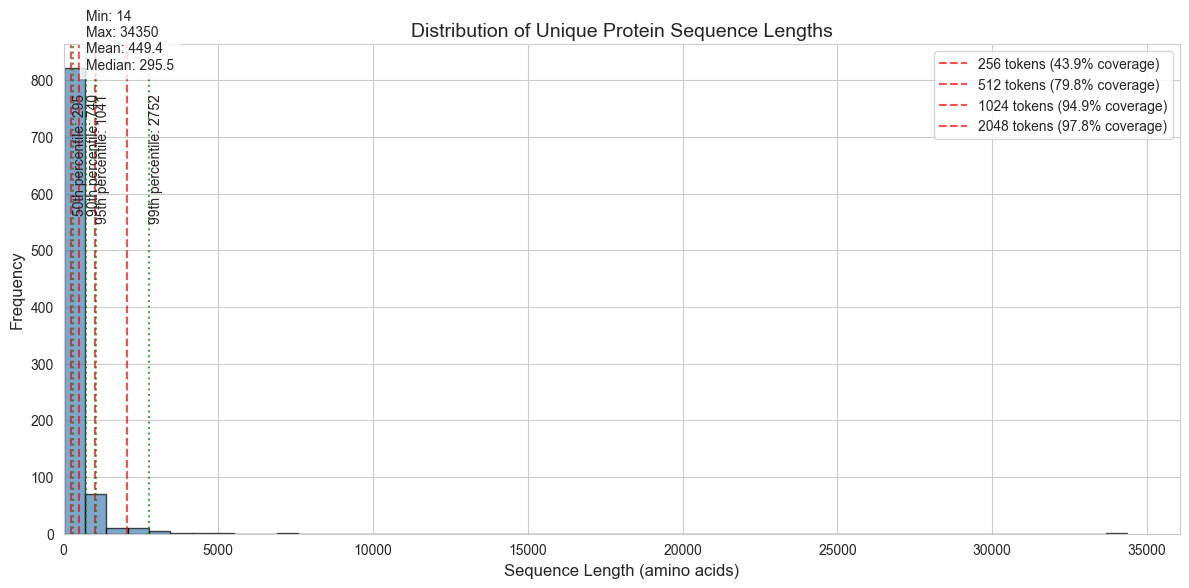

In [24]:
dataset = "protein_dataset.tsv"

def plot_sequence_length_distribution(file_path):
    sns.set_style("whitegrid")
    plt.figure(figsize=(12, 6))

    df = pd.read_csv(file_path, sep="\t")
    unique_sequences = df['Protein_Sequence'].unique()
    sequence_lengths = [len(seq) for seq in unique_sequences]

    plt.hist(sequence_lengths, bins=50, alpha=0.7, color="steelblue", edgecolor="black")

    common_lengths = [256, 512, 1024, 2048]
    for length in common_lengths:
        plt.axvline(
            x=length,
            color="red",
            linestyle="--",
            alpha=0.7,
            label=f"{length} tokens" if length == common_lengths[0] else f"{length}",
        )
        
    percentiles = [50, 90, 95, 99]
    percentile_values = np.percentile(sequence_lengths, percentiles)

    for p, val in zip(percentiles, percentile_values):
        plt.axvline(x=val, color="green", linestyle=":", alpha=0.7)
        plt.text(
            val + 10,
            plt.gca().get_ylim()[1] * 0.9,
            f"{p}th percentile: {int(val)}",
            rotation=90,
            verticalalignment="top",
        )

    coverage = {}
    for length in common_lengths:
        coverage[length] = (np.array(sequence_lengths) <= length).mean() * 100

    coverage_labels = [
        f"{length} tokens ({coverage[length]:.1f}% coverage)" for length in common_lengths
    ]
    plt.legend(coverage_labels, loc="upper right")

    plt.xlabel("Sequence Length (amino acids)", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.title("Distribution of Unique Protein Sequence Lengths", fontsize=14)

    stats_text = (
        f"Min: {min(sequence_lengths)}\n"
        f"Max: {max(sequence_lengths)}\n"
        f"Mean: {np.mean(sequence_lengths):.1f}\n"
        f"Median: {np.median(sequence_lengths)}"
    )
    plt.text(
        0.02,
        0.95,
        stats_text,
        transform=plt.gca().transAxes,
        bbox=dict(facecolor="white", alpha=0.8),
    )

    plt.xlim(left=0)
    plt.tight_layout()
    plt.show()

plot_sequence_length_distribution(dataset)

Total sequences: 29515
Sequences within length limit (30000): 29497
Sequences removed: 18 (0.06%)
Filtered data saved to: protein_dataset.tsv

Unique sequences before filtering: 923
Unique sequences after filtering: 922
Unique sequences removed: 1 (0.11%)


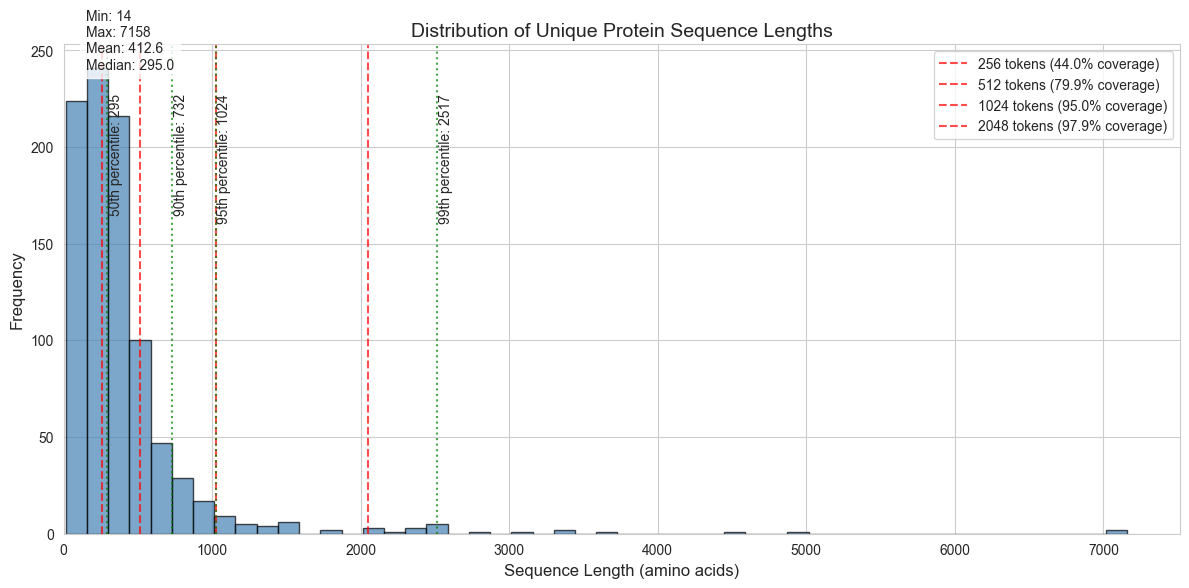

In [25]:
max_length = 30000

df = pd.read_csv(dataset, sep='\t', header=None)

sequence_col = df.iloc[:, -1]
sequence_lengths = sequence_col.str.len()
filtered_df = df[sequence_lengths <= max_length]

filtered_df.to_csv(dataset, sep='\t', header=False, index=False)

total_sequences = len(df)
filtered_sequences = len(filtered_df)
removed_sequences = total_sequences - filtered_sequences

unique_sequences_before = sequence_col.nunique()
unique_sequences_after = filtered_df.iloc[:, -1].nunique()
unique_sequences_removed = unique_sequences_before - unique_sequences_after

print(f"Total sequences: {total_sequences}")
print(f"Sequences within length limit ({max_length}): {filtered_sequences}")
print(f"Sequences removed: {removed_sequences} ({removed_sequences/total_sequences*100:.2f}%)")
print(f"Filtered data saved to: {dataset}")

print(f"\nUnique sequences before filtering: {unique_sequences_before}")
print(f"Unique sequences after filtering: {unique_sequences_after}")
print(f"Unique sequences removed: {unique_sequences_removed} ({unique_sequences_removed/unique_sequences_before*100:.2f}%)")

plot_sequence_length_distribution(dataset)

In [26]:
df = pd.read_csv(dataset, sep='\t')

found = False
for idx, row in df.iterrows():
    if row['SEC_STR'] == '-4.38':
        df.at[idx, 'SEC_STR'] = "Coil"
        found = True

if found:
    df.to_csv(dataset, sep='\t', index=False)
    print("File saved with the corrected SEC_STR value.")
else:
    print("No entry found with SEC_STR value = -4.38")

File saved with the corrected SEC_STR value.


In [27]:
COIL = 0
HELIX = 1
SHEET = 2
TURN = 3


def encode_secondary_structure(structure_text):
    """
    Encode secondary structure information as a count vector.
    Format: [coil_count, helix_count, sheet_count, turn_count]
    """
    if not structure_text or structure_text == "-":
        return [0, 0, 0, 0]

    counts = [0, 0, 0, 0]
    structures = [s.strip() for s in structure_text.split(",")]

    for structure in structures:
        if "Coil" in structure:
            counts[COIL] += 1
        elif "Helix" in structure:
            counts[HELIX] += 1
        elif "Sheet" in structure:
            counts[SHEET] += 1
        elif "Turn" in structure:
            counts[TURN] += 1

    return counts


df = pd.read_csv(dataset, sep="\t")
df["SEC_STR_ENCODED"] = df["SEC_STR"].apply(encode_secondary_structure)
df.to_csv(dataset, sep="\t", index=False)

print("\nSecondary Structure Types and Their Encodings:")
print("-" * 50)
print(f"{'Secondary Structure':<25} {'Count-Based Encoding'}")
print("-" * 50)

examples = [
    "Coil",
    "Helix",
    "Sheet",
    "Turn",
    "Helix, Sheet",
    "Helix, Turn, Turn",
    "-",
]

for example in examples:
    encoding = encode_secondary_structure(example)
    print(f"{example:<25} {encoding}")


Secondary Structure Types and Their Encodings:
--------------------------------------------------
Secondary Structure       Count-Based Encoding
--------------------------------------------------
Coil                      [1, 0, 0, 0]
Helix                     [0, 1, 0, 0]
Sheet                     [0, 0, 1, 0]
Turn                      [0, 0, 0, 1]
Coil, Coil                [2, 0, 0, 0]
Helix, Sheet              [0, 1, 1, 0]
Helix, Turn, Turn         [0, 1, 0, 2]
-                         [0, 0, 0, 0]


In [33]:
df = pd.read_csv(dataset, sep="\t")

def clean_value(value):
    if isinstance(value, str):
        if value.strip() == "-":
            return value

        if "(" in value:
            return value.split("(")[0].strip()
    return value


df_clean = df.copy()

columns_to_clean = []
for col in df_clean.columns:
    if df_clean[col].astype(str).str.contains(r"\(.*\)").any():
        columns_to_clean.append(col)

print(
    f"Found {len(columns_to_clean)} columns with bracket values: {columns_to_clean}"
)

for col in columns_to_clean:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(clean_value)
        
        if col not in ["STATE", "REVERSIBILITY", "SEC_STR", "UniProt_ID", "PDB_wild"]:
            df_clean[col] = df_clean[col].apply(
                lambda x: pd.to_numeric(x, errors="coerce") if x != "-" else x
            )

print("\nCleaned values:")
for col in df.columns:
    orig_values = df[col].astype(str).str.contains(r"\(\d+\.?\d*\)")
    if orig_values.any():
        idx = orig_values.idxmax()
        print(
            f"Column {col} - Original: {df[col][idx]} → Cleaned: {df_clean[col][idx]}"
        )

df_clean = df_clean.fillna("-")
df_clean.to_csv(dataset, sep="\t", index=False, na_rep="-")
print(f"\nCleaned dataset saved to {dataset}")

Found 12 columns with bracket values: ['Tm_(C)', '∆Tm_(C)', '∆H_(kcal/mol)', '∆Cp_(kcal/mol)', '∆HvH_(kcal/mol)', '∆G_(kcal/mol)', '∆∆G_(kcal/mol)', 'm_(kcal/mol/M)', 'Cm_(M)', '∆G_H2O_(kcal/mol)', '∆∆G_H2O_(kcal/mol)', 'REVERSIBILITY']

Cleaned values:
Column Tm_(C) - Original: 58.7(0.7) → Cleaned: 58.7
Column ∆Tm_(C) - Original: 61.9 (0.4) → Cleaned: 61.9
Column ∆H_(kcal/mol) - Original: 15.8 (0.29) → Cleaned: 15.8
Column ∆Cp_(kcal/mol) - Original: -1.44 (0.24) → Cleaned: -1.44
Column ∆HvH_(kcal/mol) - Original: 104 (0.49) → Cleaned: 104
Column ∆G_(kcal/mol) - Original: 9.81 (0.18) → Cleaned: 9.81
Column ∆∆G_(kcal/mol) - Original: -0.76 (0.9) → Cleaned: -0.76
Column m_(kcal/mol/M) - Original: 1.1 (0.2) → Cleaned: 1.1
Column Cm_(M) - Original: 1.86(0.01) → Cleaned: 1.86
Column ∆G_H2O_(kcal/mol) - Original: 2.95 (0.19) → Cleaned: 2.95
Column ∆∆G_H2O_(kcal/mol) - Original: 0.62 (0.06) → Cleaned: 0.62
Column REVERSIBILITY - Original: yes(0.94) → Cleaned: yes

Cleaned dataset saved to pro

In [43]:
df = pd.read_csv(dataset, sep='\t')

def map_reversibility(value):
    if isinstance(value, str):
        if value.lower() == "yes":
            return 1.0
        elif value.lower() == "no":
            return 0.0
        elif value.lower() in ["unknown", "unknownnouwn"] :
            return -1.0
        elif value.lower() == "partially reversible":
            return 0.5
        elif value.lower() == "yes, 90%":
            return 0.9
        elif value.lower() == "70% reversible":
            return 0.7
        elif value.lower() == "> 90%":
            return 0.95
    return value

df['REVERSIBILITY'] = df['REVERSIBILITY'].apply(map_reversibility)

df.to_csv(dataset, sep='\t', index=False)
print("File saved with the updated REVERSIBILITY values.")

File saved with the updated REVERSIBILITY values.


Null handling

In [45]:
dataset = "protein_dataset.tsv"
dataset_null_handled = "protein_dataset_numeric.tsv"

df = pd.read_csv(dataset, sep="\t")

df.replace("-", np.nan, inplace=True)

df["ASA"] = df["ASA"].fillna(-1)    # Flag
df["pH"] = df["pH"].fillna(7.0)    # Mode 
df["T_(C)"] = df["T_(C)"].fillna(25.0)    # Mode
df["REVERSIBILITY"] = df["REVERSIBILITY"].fillna(-1)    # Flag

df["ASA"] = df["ASA"].astype(float)
df["pH"] = df["pH"].astype(float)
df["T_(C)"] = df["T_(C)"].astype(float)
df["REVERSIBILITY"] = df["REVERSIBILITY"].astype(float)

df.to_csv(dataset_null_handled, sep="\t", index=False)
print(f"Null values have been handled successfully and saved to: {dataset_null_handled}")

Null values have been handled successfully and saved to: protein_dataset_numeric.tsv
